In [8]:
import matplotlib.pyplot as plt
import numpy as np
from functions import *
import pandas as pd

lyr_2_au = 63241.1

In [10]:
pldata = pd.read_csv('PS_2024.01.22_04.17.20.csv', skiprows = 100)
pldata = pldata.iloc[np.where(pldata['pl_controv_flag'] == 0)]

For your reference:
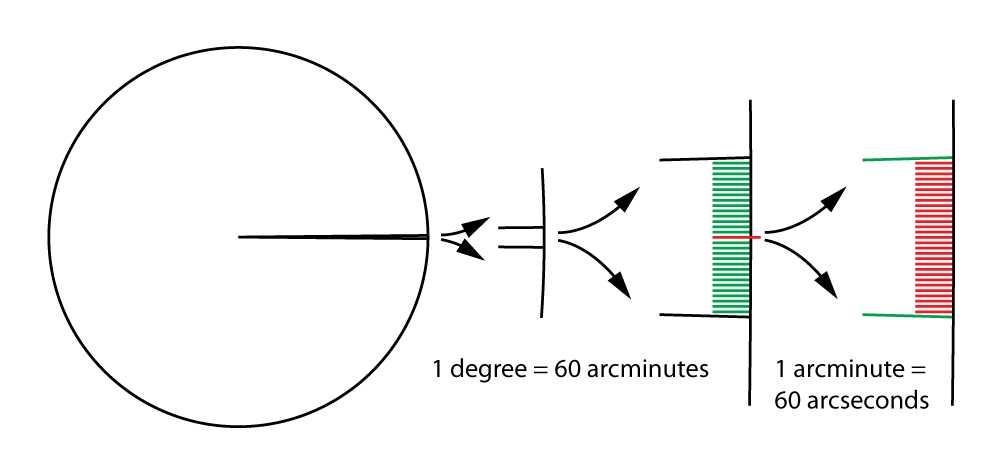

### 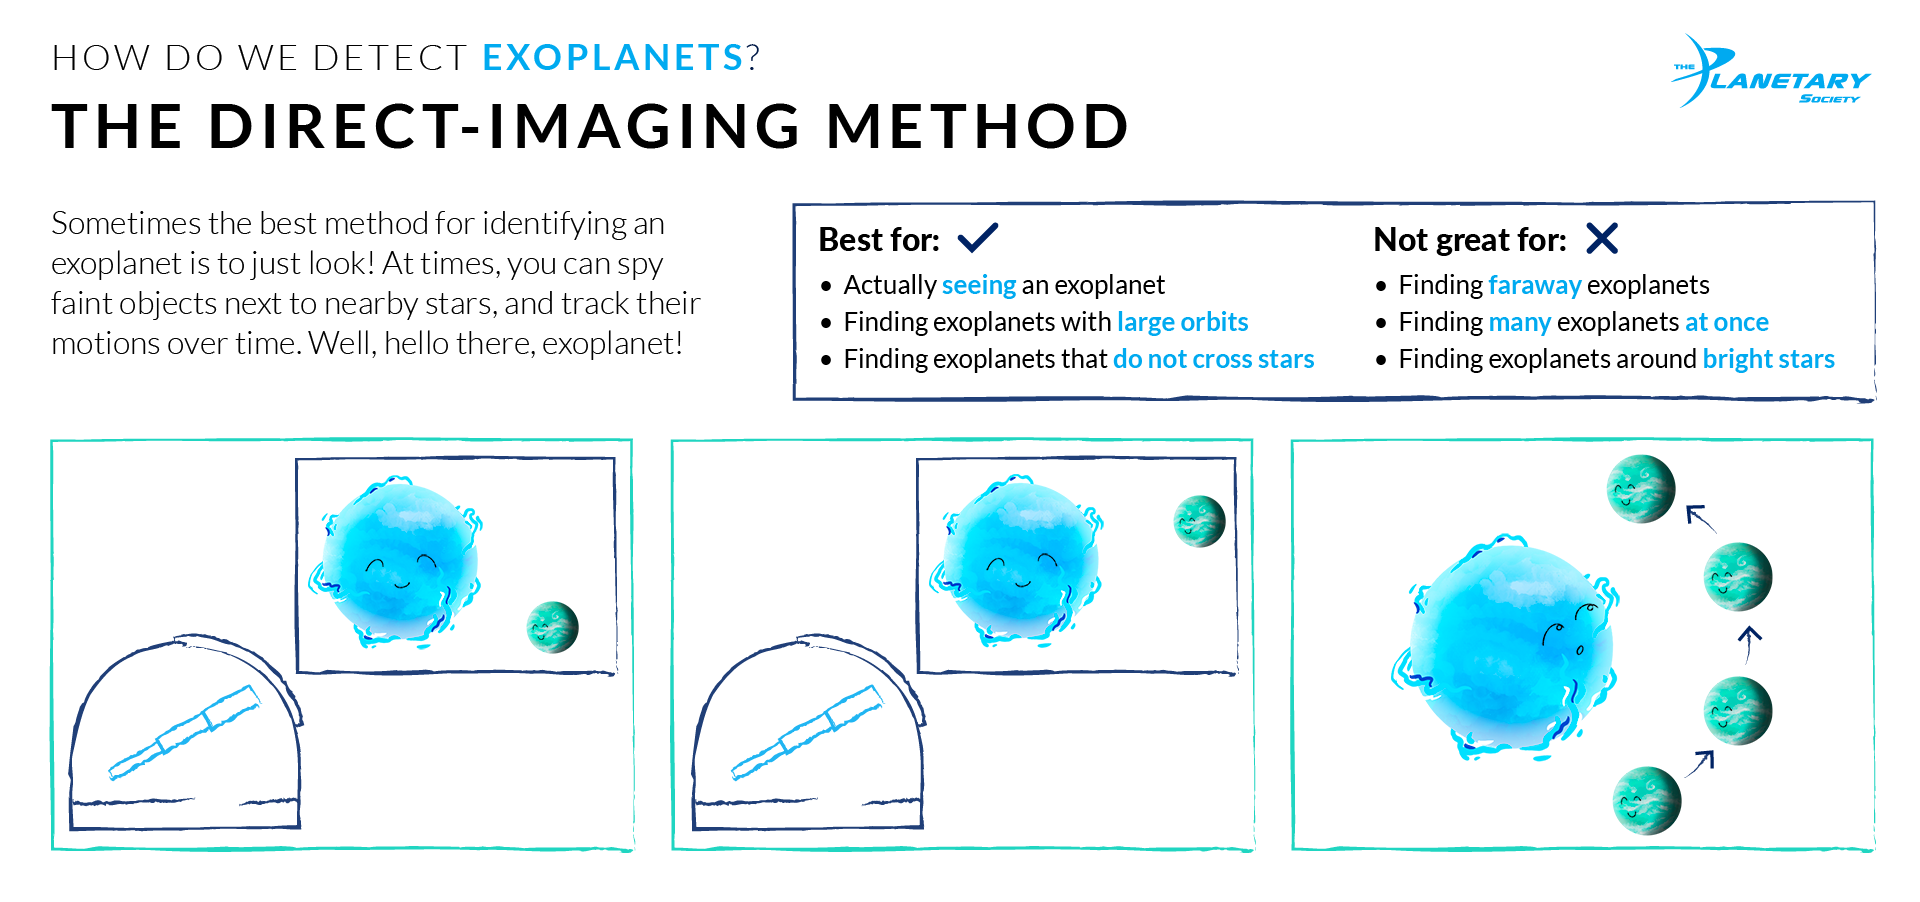

Consider the configuration below: a planet with a semi-major axis, a, that is a distance d away from us (the observer). 

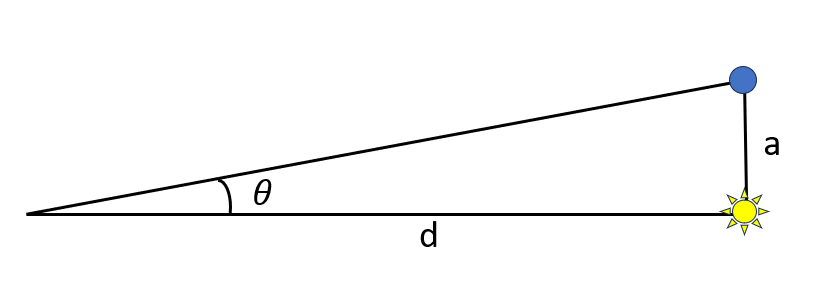

We will see an angular seperation between the star and planet given by

$$\LARGE \theta \simeq \frac{a}{d}$$

### Convince yourself that the small angle approximation is valid. Look at the NEA data for Prox Cen b (https://exoplanetarchive.ipac.caltech.edu/overview/proxima%20centauri%20c), our nearest planetary neighbor. How much does the small angle approximation differ from the exact solution for this planet? How about something at the distance of Jupiter? Twice that? At what approximate (order of mag) semi-major axis is the fractional difference between the approximation and exact solution of order 1.

Note: make sure your units are consistent between a and d!!

For a telescope with diameter D observing at some wavelength $\lambda$, the minimum resolvable angular seperation (a.k.a. the angular resolution is given by the Rayleigh criterion (see http://hyperphysics.phy-astr.gsu.edu/hbase/phyopt/Raylei.html)

$$\LARGE \theta_{min} \simeq 1.22 \frac{\lambda}{D}$$.

To resolve the planet from the star then the following must be satisfied:

$$\LARGE \frac{a}{d} \geq \theta_{min}$$

Just looking at the equation above, discuss with your group what semi-major axes and distances are favored by this technique.

Assuming the above is satisfied for whatever planet you are looking at, then whether or not you can actually image the planet depends on how much light it gives off and how much it constrasts the host star. The planet will both emit its own light (blackbody radiation) and reflect some fraction of the host star's light. 

For the plot below:
- top left = semi-major axis vs distance to star. The gray region corresponds to unresolvable angular seperations (i.e., $ \frac{a}{d} \geq \theta_{min}$ is not satisfied)
- bottom left = cumulative histogram of all planet hosts within 100 lyr of our Solar System.
- top right = star-planet contrast including both the reflected and emitted components. 
- bottom right = planck function (artificially scaled) for both your planet and star. All you need to know for now is that the Planck function shows how much light an object of temperature T emits as a function of wavelength. 

### By changing the plot inputs below, discuss the following with your group:
- What is the approx minimum telescope diameter/ you need to resolve the Earth (Rplanet = 1.0, au = 1.0) that is 4, 10, 100 light years away?
- With a telescope diameter of 10 meters, how far away would you be able to resolve Jupiter (Rplanet ~ 11 Re, a = 5.2 au)? How many systems are within this distance? Repeat for some other values of a (say a = 20.0 au)
- Most direct imaging is done in the infared. Why might that be?
- What wavelength range does the Sun emit most of its light in? How does this compare with the wavelength range that our eyes operate in?



<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
/var/folders/fn/ftdxnvm95w77wx4hbl6fwn7r0000gn/T/ipykernel_40489/1313217140.py:50: SyntaxWarning: invalid escape sequence '\l'
  ax[1,1].plot(lam, planck_function(equilibrium_temperature(Tstar, Rstar*0.00465047, a), lam*1e-7)/np.mean(2*planck_function(equilibrium_temperature(Tstar, Rstar*0.00465047, a), lam*1e-7)), 'c-', label = 'Planet ($\lambda_{peak} \sim$' + str(round(lampeak_planet,0)) + 'nm)')


Equilibrium Temp =  278.0 K
Equilibrium Temp =  278.0 K
Equilibrium Temp =  278.0 K


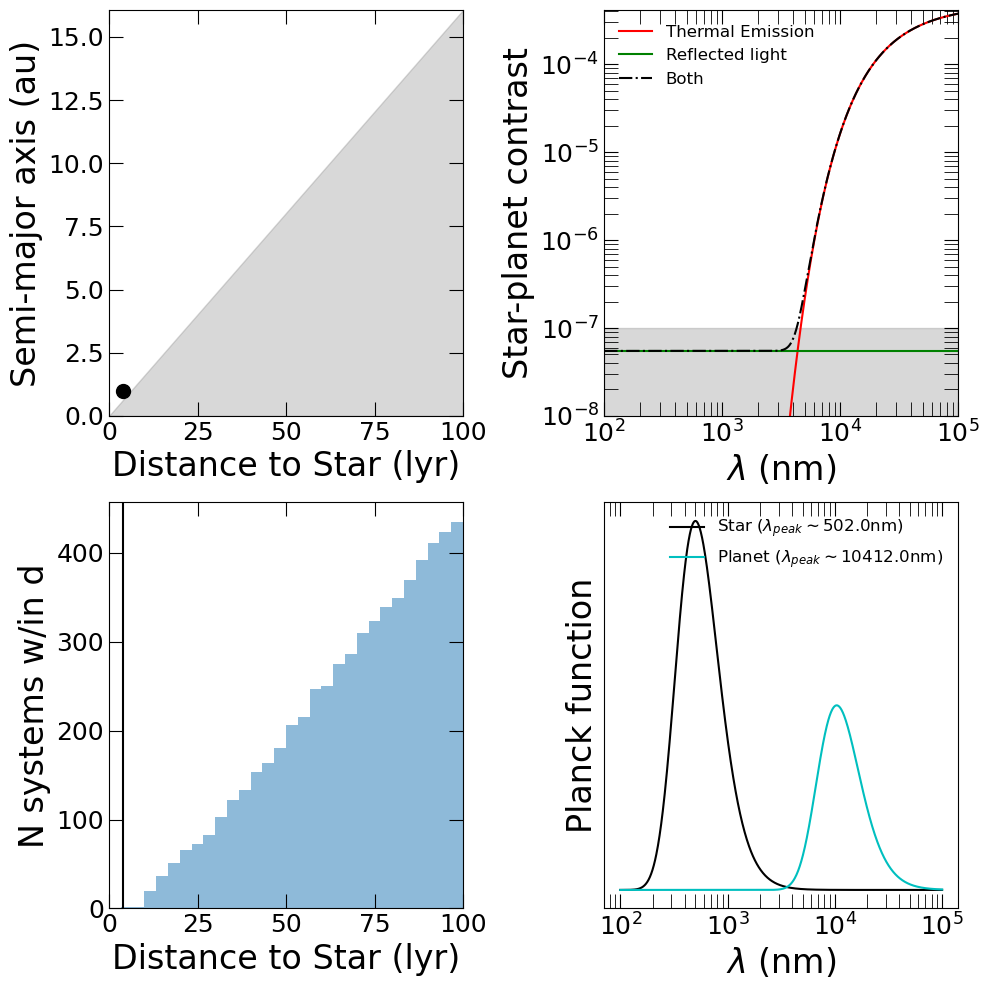

In [21]:
#---------------------------------------INPUTS---------------------------------------------------------#
#Telescope parameters
D = 5.0 #diameter

Tstar = 5772.0 #effective temperature of the star - 5772 K = the Sun
Rplanet = 11.0 #Earth radii
dist_to_star = 4.0 #light years
a = 1.0 #AU
Rstar = 1.0 #solar radii
#------------------------------------------------------------------------------------------------#



lambda_planet = 2898.0/equilibrium_temperature(Tstar, Rstar*0.00465047, a)
theta_min = (1.22*lambda_planet*(10**(-6)))/D

fig, ax = plt.subplots(2,2, figsize = (10,10))
ax[0,0].fill_between(np.linspace(0.0, 100, 100), np.linspace(0.0, 100, 100)*lyr_2_au*theta_min, alpha = 0.3, color = 'gray')
ax[0,0].set_xlim(4.0, 100)
ax[0,0].set_ylim(0,max(np.linspace(0.0, 100, 100)*lyr_2_au*theta_min))
ax[0,0].set_xlabel('Distance to Star (lyr)', fontsize = 24)
ax[0,0].set_ylabel('Semi-major axis (au)', fontsize = 24)
ax[0,0].plot(dist_to_star, a, 'ko', markersize = 10)



lam = 10**np.linspace(np.log10(100), np.log10(100*1000), 1000)


ax[0,1].plot(lam, thermal_contrast(lam, Tstar, Rstar, Rplanet, a), 'r-', label = 'Thermal Emission')
ax[0,1].plot(lam, np.ones(len(lam))*reflected_contrast(Rplanet, a), 'g-', label = 'Reflected light')
ax[0,1].plot(lam, np.ones(len(lam))*reflected_contrast(Rplanet, a) 
           + thermal_contrast(lam, Tstar, Rstar, Rplanet, a), 'k-.', label = 'Both')

ax[0,1].legend(frameon = False, fontsize = 12)
ax[0,1].fill_between([min(lam), max(lam)], [10**(-7), 10**(-7)], color = 'gray', alpha = 0.3)
ax[0,1].set_xlim([min(lam), max(lam)])

ax[0,1].set_ylim(10**(-8), 1.1*max([max(thermal_contrast(lam, Tstar, Rstar, Rplanet, a)), reflected_contrast(Rplanet, a)]))
ax[0,1].set_xlabel(r'$\lambda$ (nm)', fontsize = 24)
ax[0,1].set_ylabel(r'Star-planet contrast', fontsize = 24)


ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')

lampeak = 2898*1000.0/Tstar
ax[1,1].plot(lam, planck_function(Tstar, lam*1e-7)/np.mean(planck_function(Tstar, lam*1e-7)), 'k-', label = r'Star ($\lambda_{peak} \sim$' + str(round(lampeak,0)) + 'nm)')
lampeak_planet = 2898*1000.0/equilibrium_temperature(Tstar, Rstar*0.00465047, a)
ax[1,1].plot(lam, planck_function(equilibrium_temperature(Tstar, Rstar*0.00465047, a), lam*1e-7)/np.mean(2*planck_function(equilibrium_temperature(Tstar, Rstar*0.00465047, a), lam*1e-7)), 'c-', label = 'Planet ($\lambda_{peak} \sim$' + str(round(lampeak_planet,0)) + 'nm)')
ax[1,1].set_ylabel('Planck function', fontsize = 24)
ax[1,1].set_yticks([], labels = [])
ax[1,1].legend(frameon = False, fontsize = 12, loc = 'upper right')

ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

ax[0,0].tick_params(which = 'both', labelsize = 18, direction = 'in', top = True, right = True, length = 10)
ax[0,1].tick_params(which = 'both', labelsize = 18, direction = 'in', top = True, right = True, length = 10)
ax[1,1].tick_params(which = 'both', labelsize = 18, direction = 'in', top = True, right = True, length = 10)
ax[1,0].tick_params(which = 'both', labelsize = 18, direction = 'in', top = True, right = True, length = 10)


ax[0,1].set_xticks([100, 1000, 10000, 100000])
ax[1,1].set_xticks([100, 1000, 10000, 100000])


ax[1,1].set_xlabel(r'$\lambda$ (nm)', fontsize = 24)

#ax[1,0].axis('off')

ax[1,0].hist(pldata['sy_dist']*3.2615637769, bins = 30, range = (0, 100), cumulative = True, alpha = 0.5)
ax[1,0].set_xlim(0, 100)
ax[1,0].axvline(dist_to_star, color = 'k')
ax[1,0].set_xlabel(r'Distance to Star (lyr)', fontsize = 24)
ax[1,0].set_ylabel(r'N systems w/in d', fontsize = 24)
#ax[1,0].set_yscale('log')
ax[0,0].set_xlim(0, 100)


plt.tight_layout()

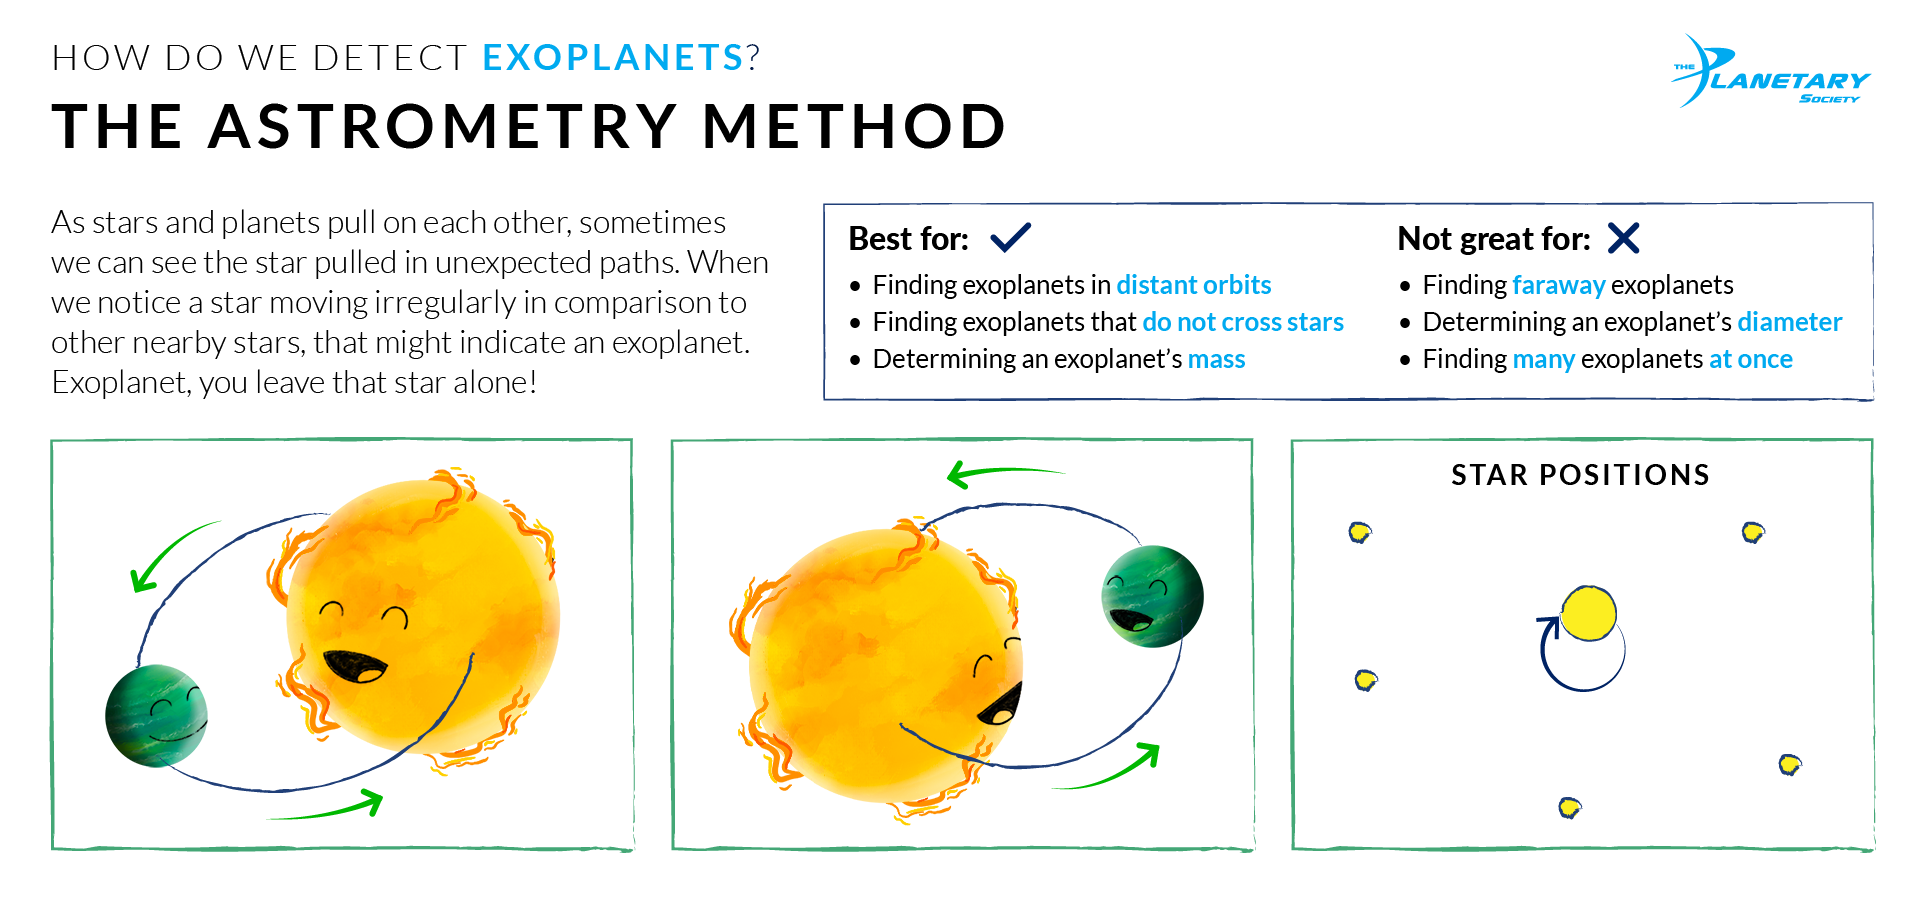

The astrometric signal of a planet of mass $M_p$ orbiting a star of mass $M_\star$ with a semi-major axis $a$ that is $d$ away from the observer is given by

$$\LARGE\theta = \left(\frac{M_p}{M_\star}\right)\frac{a}{d}$$

Similar to direct imaging, there is a minimum $\theta$ that we can resolve. Plugging in some $\theta_{min}$ and solving for $M_p$ gives the minimum planet mass that we can resolve as a function of $d$, $a$, and $\theta_{min}$.

Rearranging for planet mass (since this is the variable we are trying to measure) gives

$$\LARGE M_{p,min} = \theta_{min} M_\star \frac{d}{a}$$

Just looking at this equation, how does the minimum measureable planet mass change with each of the parameters?

Now I'm going to adopt the angular resolution of the 
$$\LARGE \theta_{min}\sim 400 \mu as$$

The plot below shows a color map of the minimum detectable planet mass around a star with $M_{star}$ as a function of $a$ and $d$. Any planet masses specified in the 'mass_levels' array will show up as black lines on the plot. I have it set up to show an Earth mass planet and Jupiter mass

### Discuss with your group:
- Can you detect an Earth mass planet at 1 AU with this technique?
- Can you detect a Jupiter mass planet at 5.2 AU with this technique? How close does the system need to be? Approximately how many systems are within that distance (reference the plot above)?

Text(0, 0.5, '$\\log_{10}$(a/au)')

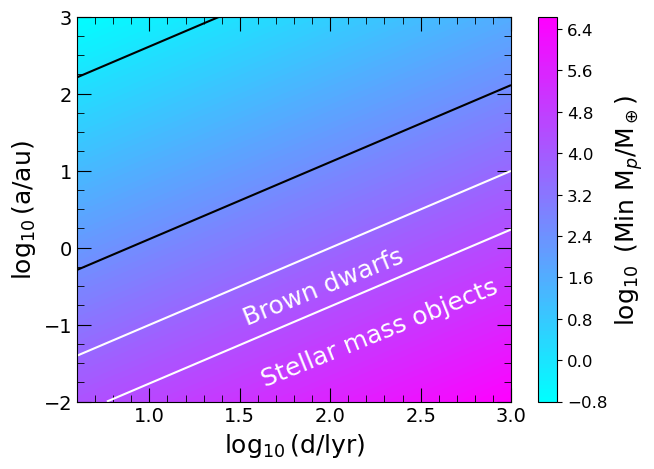

In [25]:
#------------------------------------------------Inputs------------------------------------------------------------#
Mstar = 1.0 #Solar mass units
mass_levels = [1.0, 317.0] #Earth mass units
#------------------------------------------------------------------------------------------------------------------#


a = np.linspace(0.01, 1000, 1000)
d = np.linspace(4.0, 1000.0, 1000)
d,a = np.meshgrid(d, a)
Z = min_planet_mass(Mstar, a, d)

plt.figure(figsize = (7,5))
plt.contourf(np.log10(d), np.log10(a), np.log10(Z), levels = 100, cmap = 'cool')
cb = plt.colorbar()
cb.set_label(label = r'$\log_{10}$ (Min M$_p$/M$_\oplus$)', size= 18)
cb.ax.tick_params(labelsize='large')

mass_levels = np.array([np.log10(mass) for mass in mass_levels])
plt.contour(np.log10(d), np.log10(a), np.log10(min_planet_mass(Mstar, a, d)), levels = mass_levels, colors = 'k')
plt.contour(np.log10(d), np.log10(a), np.log10(min_planet_mass(Mstar, a, d)), levels = [np.log10(317.0*13), np.log10(317.0*75)], colors = 'w')
plt.text(1.5, -1.0, 'Brown dwarfs', fontsize = 18, rotation = 22, color = 'w')
plt.text(1.6, -1.8, 'Stellar mass objects', fontsize = 18, rotation = 22, color = 'w')

plt.xticks(np.linspace(0.5, 3.0, int(2.5/0.1)+1), minor = True)
plt.xlim(0.6, 3)

plt.yticks(np.linspace(-2, 3.0, int(5/0.25)+1), minor = True)
#plt.xlim(0.6, 3)

plt.tick_params(which = 'major', labelsize = 14, top = True, right = True, direction = 'in', length = 10)
plt.tick_params(which = 'minor', labelsize = 14, top = True, right = True, direction = 'in', length = 5)

plt.xlabel(r'$\log_{10}$(d/lyr)', fontsize = 18)
plt.ylabel(r'$\log_{10}$(a/au)', fontsize = 18)

#plt.axhline(np.log10(5.2))


### Given what you've learned, do any of the numbers below surprise you?

In [28]:
print('Total planet detections = ', len(pldata))
print('Detections by Astrometry = ', len(np.where(pldata['discoverymethod'] == 'Astrometry')[0]))
print('Detections by imaging = ', len(np.where(pldata['discoverymethod'] == 'Imaging')[0]))

Total planet detections =  5539
Detections by Astrometry =  3
Detections by imaging =  66
